In [ ]:
from copy import deepcopy
import numpy as np
import random 
import sys 
import string
import torch
from torch.nn.functional import softmax
import seaborn as sns
import matplotlib.pyplot as plt

from decoderlens import DecoderLens
from extractor import Extractor
import analysis_utils as anu
from analysis_utils import plot_hidden_states


sys.path.append("../")

from checkpoint import CheckPoint
from datasets import LetterStringDataLoader
from evaluate import predict_batch

BATCH_SIZE = 1
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
%config InlineBackend.figure_format = 'retina'

In [44]:
# load checkpoints:
copy_rand_perm20 = CheckPoint.from_pt("../models/copy_batching_experiments/MLC_batchrand_dallstudy1_copy_perm20_nep20.pt")
rand_perm20 = CheckPoint.from_pt("../models/batching_experiments/MLC_batchrand_dallstudy1_nep20.pt")
alph_perm200 = CheckPoint.from_pt("../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")

# load models and dataset:
model_copy = copy_rand_perm20.load_model(verbose=False)
model_unstruct = rand_perm20.load_model(verbose=False)
model_best = alph_perm200.load_model()
dataloader = LetterStringDataLoader(
    mode="test", 
    data_dir="../data/letter-string-analogies/perturbation_dataset", 
    batch_size=BATCH_SIZE, 
    batching_method="random"
)
trans = "pred"
dataloader.dataset.set_filter("transformation_alphabet", [" | ".join([trans, " ".join(list(string.ascii_lowercase))])])

Loading model that has completed 19 of 20 epochs
	batch size: 32
	number of steps: 219,659
	best val loss achieved: 0.6038
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


In [48]:
extractor = Extractor(model_best)
extractor.register()

# run model on batch
batch = next(iter(dataloader))
model_best.eval()
with torch.no_grad():
    output = model_best(batch["yq_io_padded"], batch)

# save hidden states from pred example:
hidden_states_pred = deepcopy(extractor.hidden_states)
print(" ".join(batch["xq_context"][0]))

a b c d e f g h i j k l m n o p q r s t u v w x y z SOS g h i IO f h i SOS b c d


In [49]:
class Perturber:
    def __init__(self, model) -> None:
        self.model = model
        self.hidden_state_perturbation = None

    def insert_hidden_states(self, hidden_states: torch.Tensor, layer: int):
        """Insert hidden states that will be used in the next forward pass of the model.

        Args:
            hidden_states (torch.Tensor): hidden states to insert.
            layer (int): Layer in which to insert them
        """
        self.hidden_state_perturbation = {
            "layer": layer,
            "hidden_states": hidden_states
        }
    
    def insert_attention_pattern(self, pattern, layer: int, head: int):
        """Insert an attention pattern into a layer head of the encoder and use this pattern instead for the forward pass

        Args:
            pattern (_type_): _description_
            layer (int): _description_
            head (int): _description_
        """
        ...

    @torch.no_grad()
    def get_encoder_outputs(self, batch):
        """Generate encoder outputs with the applied perturbations."""
        # normal forward pass if 
        if not self.hidden_state_perturbation:
            hidden_states, _ = self.model.encode(batch)
            return hidden_states

        start_layer_idx = self.hidden_state_perturbation["layer"] + 1
        hidden_states = self.hidden_state_perturbation["hidden_states"]
        
        # if perturbation is already at the final layer, return perturbed states directly:
        if start_layer_idx >= self.model.nlayers_encoder:
            return hidden_states
        else:
            # Get padding mask (required for Transformer layers to ignore PAD tokens)
            xq_context_padded = batch['xq_context_padded']
            src_padding_mask = xq_context_padded == self.model.PAD_idx_input
            # Iterate through remaining encoder layers:
            for i in range(start_layer_idx, self.model.nlayers_encoder):
                hidden_states = self.model.transformer.encoder.layers[i](
                    hidden_states, 
                    src_mask=None, 
                    src_key_padding_mask=src_padding_mask
                )
            return self.model.transformer.encoder.norm(hidden_states)

### Visualize hidden states from predecessor example

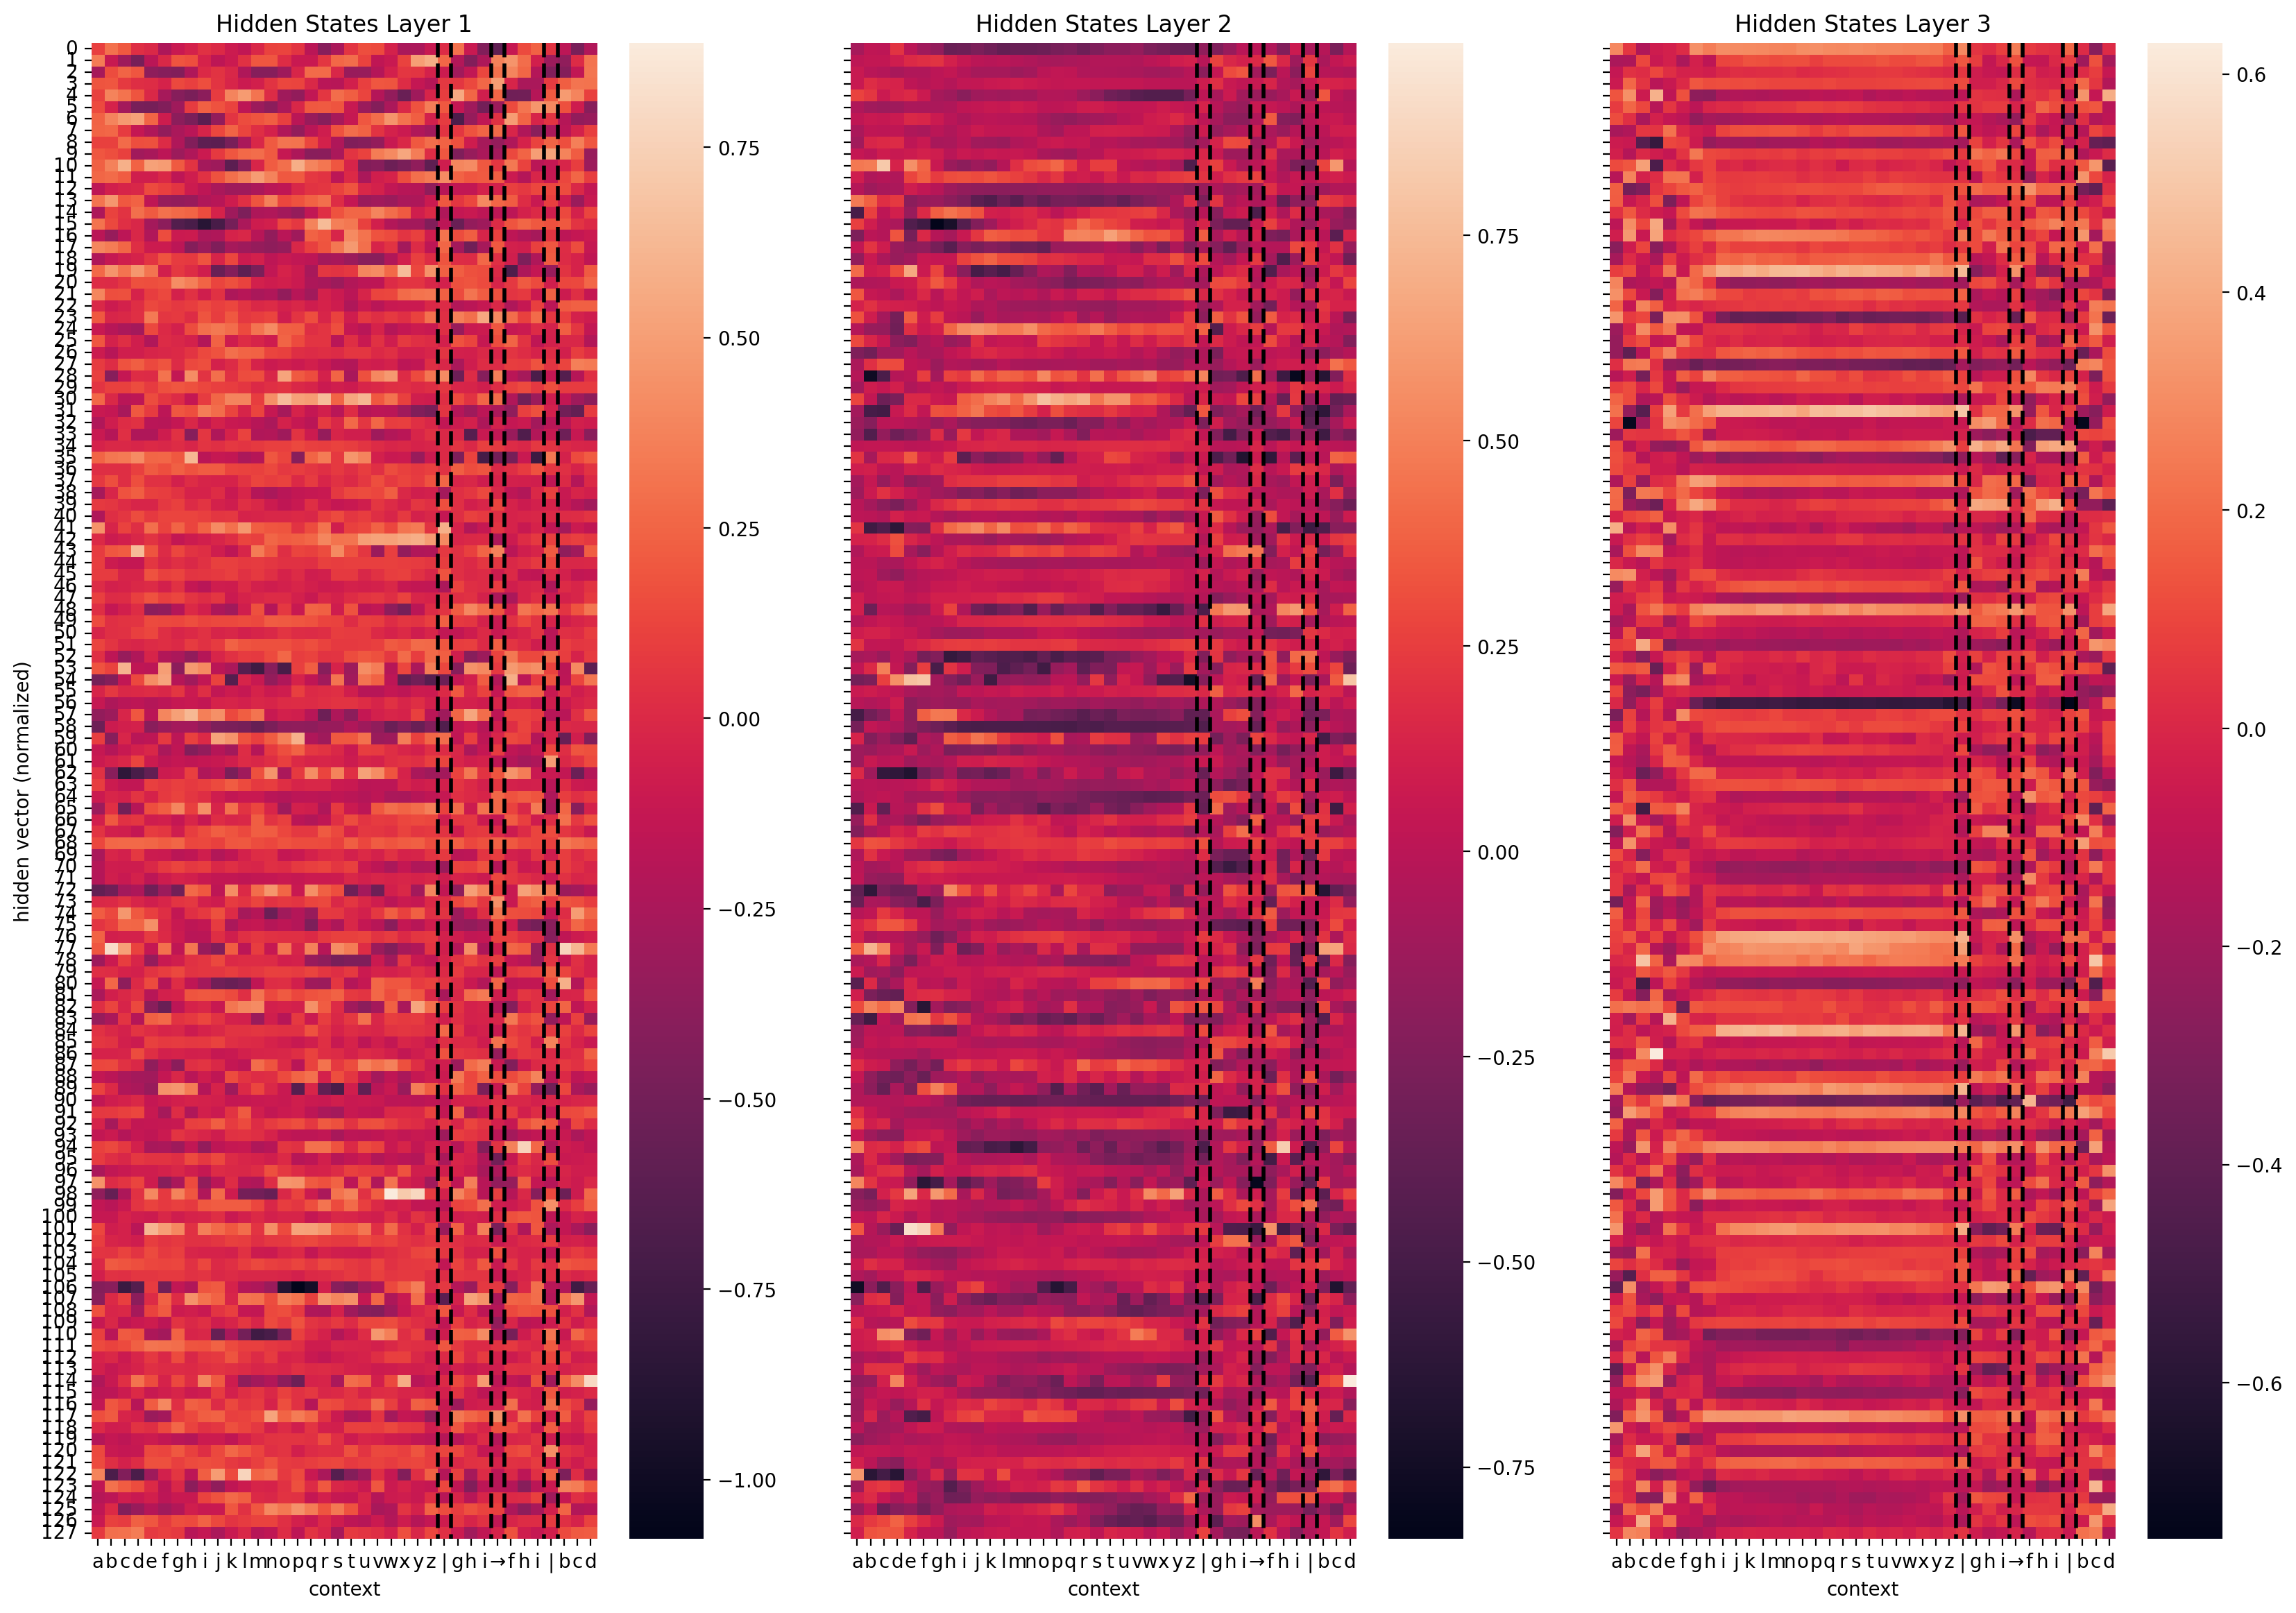

In [51]:
_ = plot_hidden_states(extractor, batch, idx=0)

### Apply perturbation to successor example:

In [53]:
# generate from successor example:
extractor.clear()
trans = "succ"
dataloader.dataset.set_filter("transformation_alphabet", [" | ".join([trans, " ".join(list(string.ascii_lowercase))])])

# run model on batch
batch = next(iter(dataloader))
model_best.eval()
with torch.no_grad():
    output = model_best(batch["yq_io_padded"], batch)

print(" ".join(batch["xq_context"][0]))

a b c d e f g h i j k l m n o p q r s t u v w x y z SOS g h i IO g h j SOS b c d


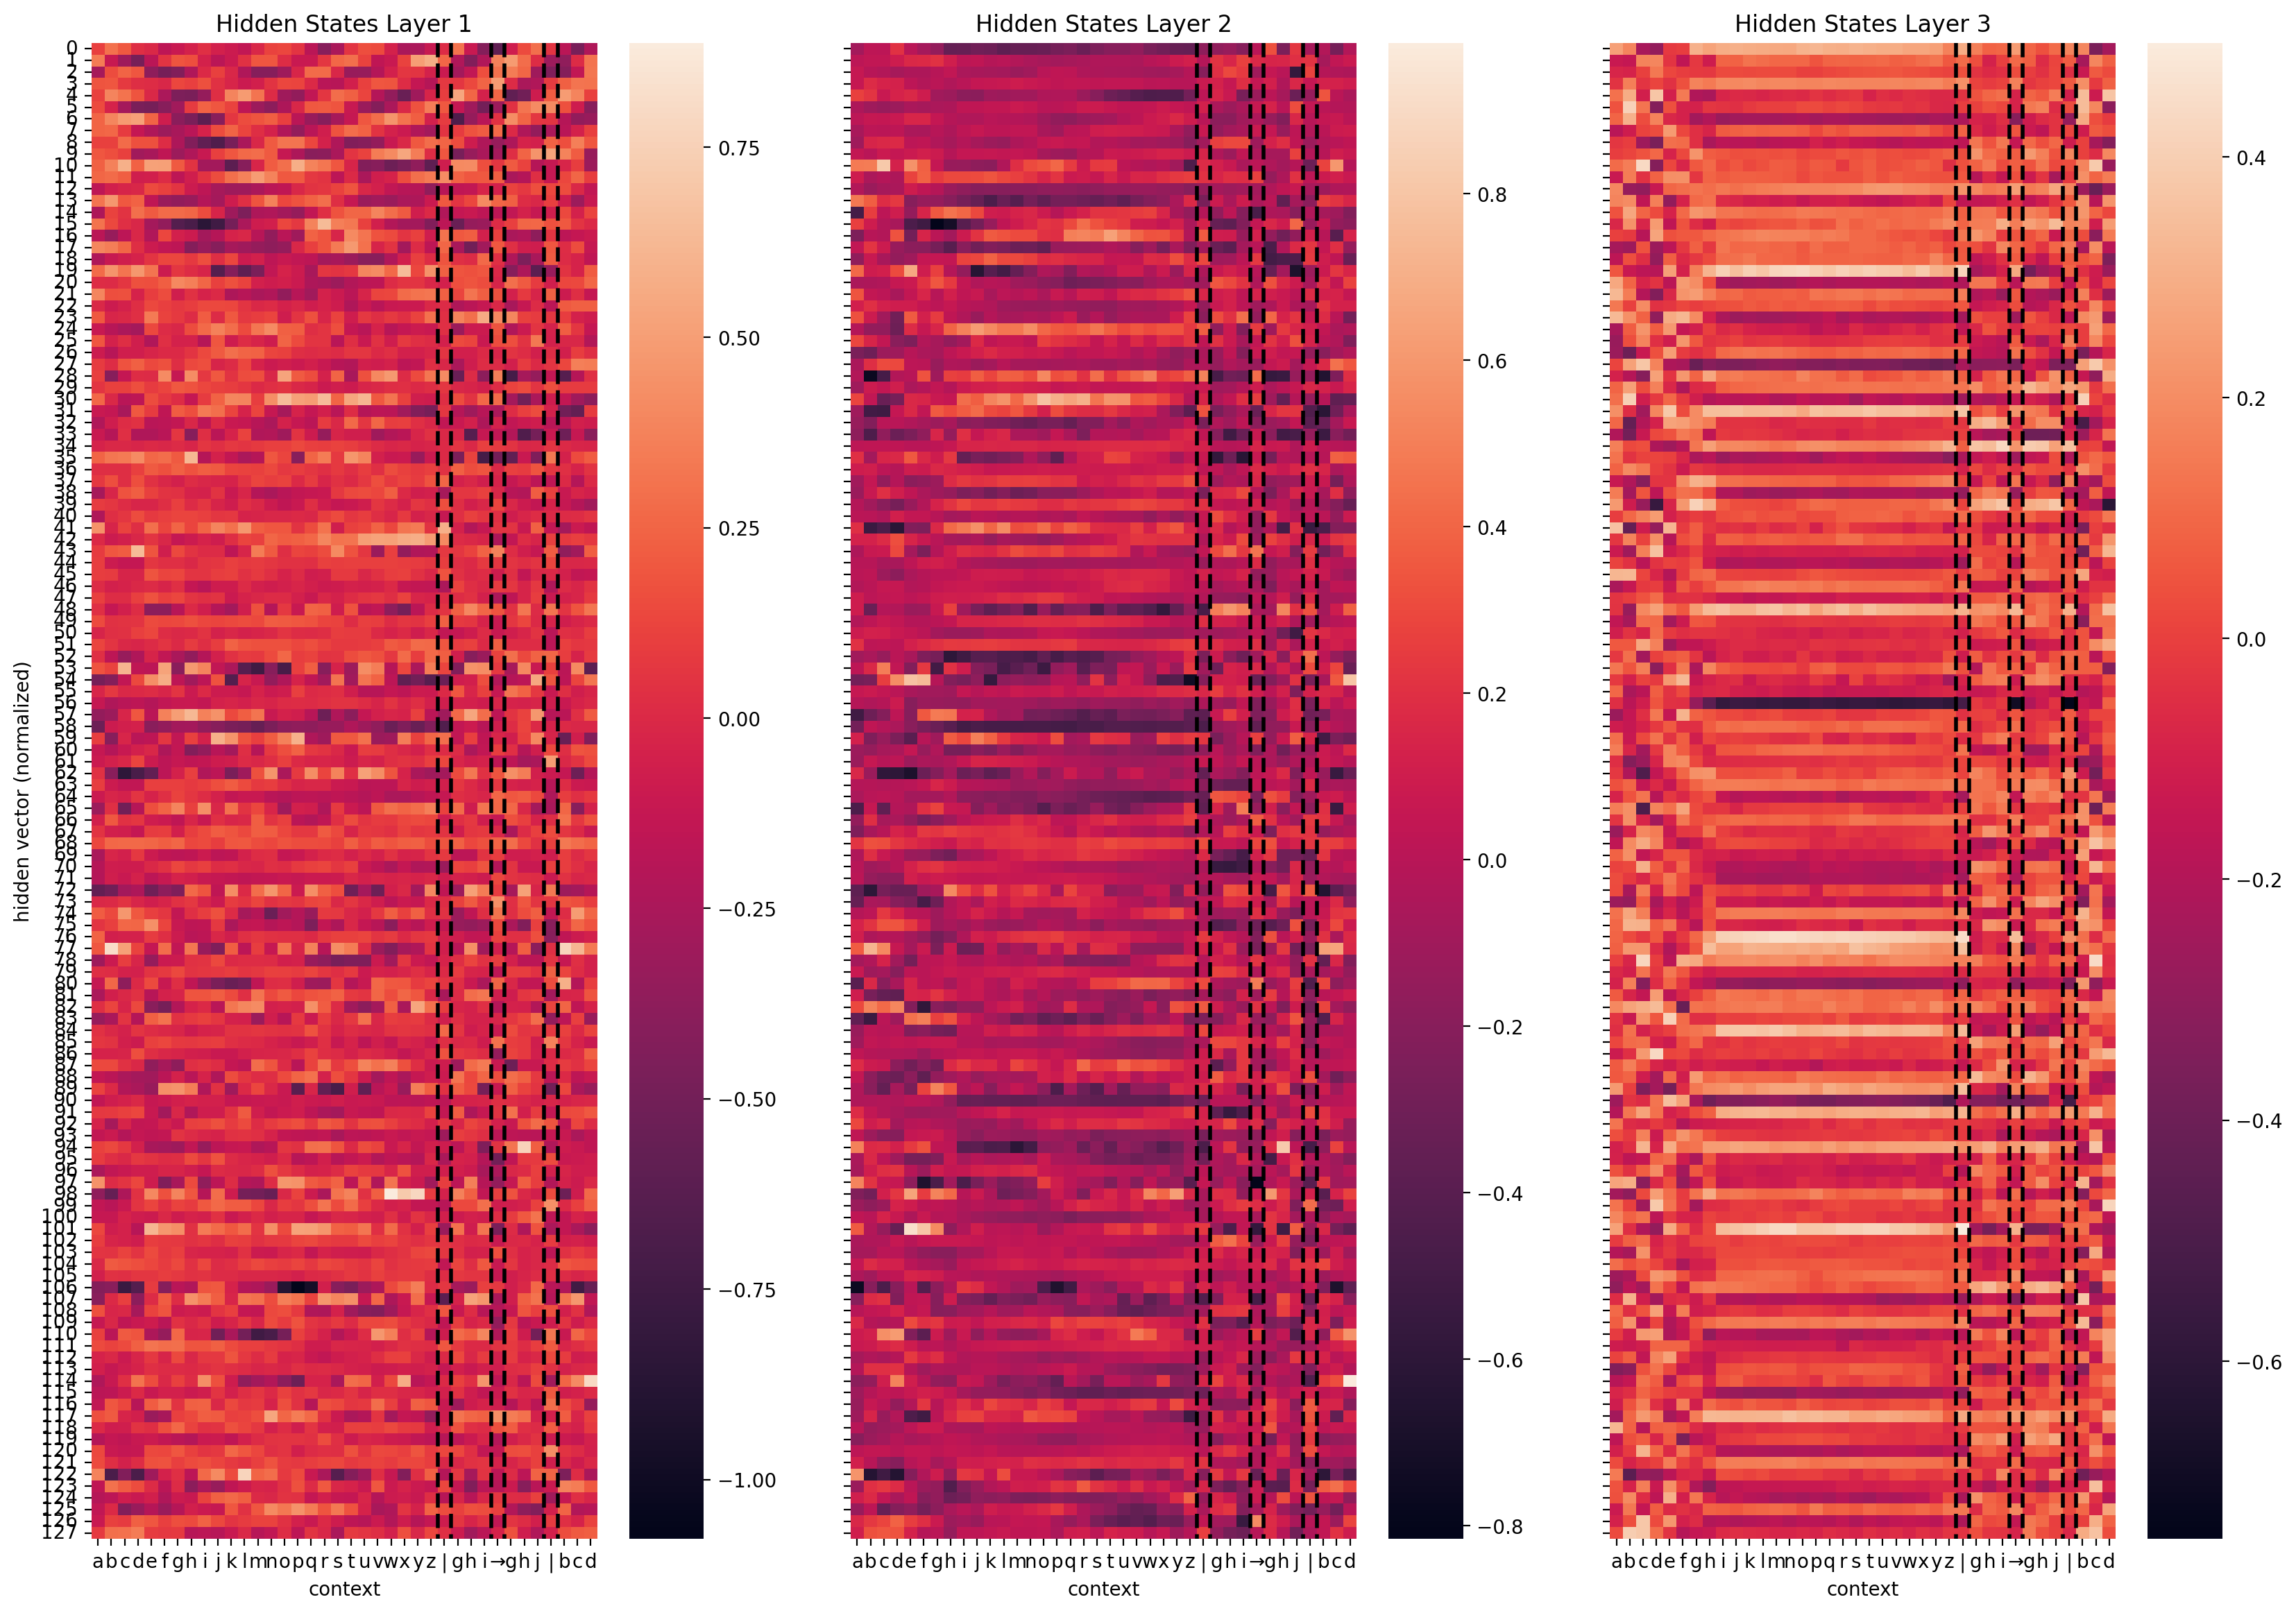

In [55]:
_ = plot_hidden_states(extractor, batch, idx=0)

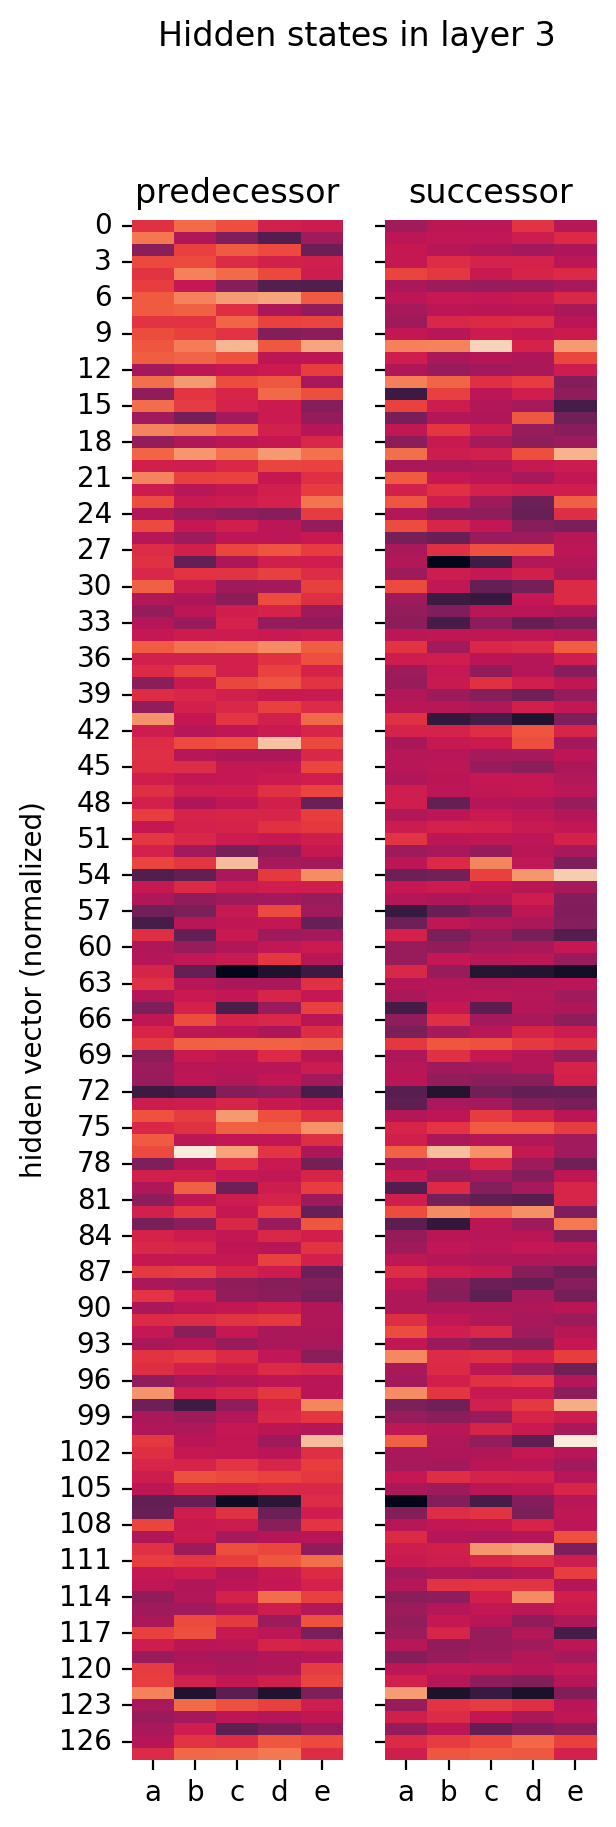

In [62]:
# compare how both represent bcd
ids = [0,1,2,3,4]
layer = 2
# plot encoder representations:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(3, 10))
plt.suptitle("Hidden states in layer 3")
labels = anu.format_context_labels(batch, 0)
hidden_states_succ = deepcopy(extractor.hidden_states)
for i, hidden_states in enumerate([hidden_states_pred, hidden_states_succ]):
    sns.heatmap(
        hidden_states[f'layer_{i}'][0][ids].T, 
        ax=ax[i], 
        xticklabels=[lab for num, lab in enumerate(labels) if num in ids],
        cbar=False
    )
    if i==0:
        ax[i].set_title("predecessor")
        ax[i].set_ylabel("hidden vector (normalized)")
    else:
        ax[i].set_title("successor")
    ax[i].tick_params(axis='x', labelrotation=0)

In [63]:
perturber = Perturber(model_best)
decoderlens = DecoderLens(model_best)

In [228]:
def plot_probs(predictions, logits, language):
    fig, ax = plt.subplots(1, len(predictions)+1, figsize=(20,5))
    for gen_token in range(len(predictions)+1):
        probs = softmax(logits[:,gen_token], dim=0)
        labels = [language.index2symbol[i] for i in range(30)]
        ax[gen_token].bar(x=labels, height=probs)
        predicted_letters = ''.join(predictions[:gen_token]) if gen_token>0 else ''
        ax[gen_token].set_title(f"P(letter| {predicted_letters}, context)")
    plt.show()

['b', 'c', 'e']


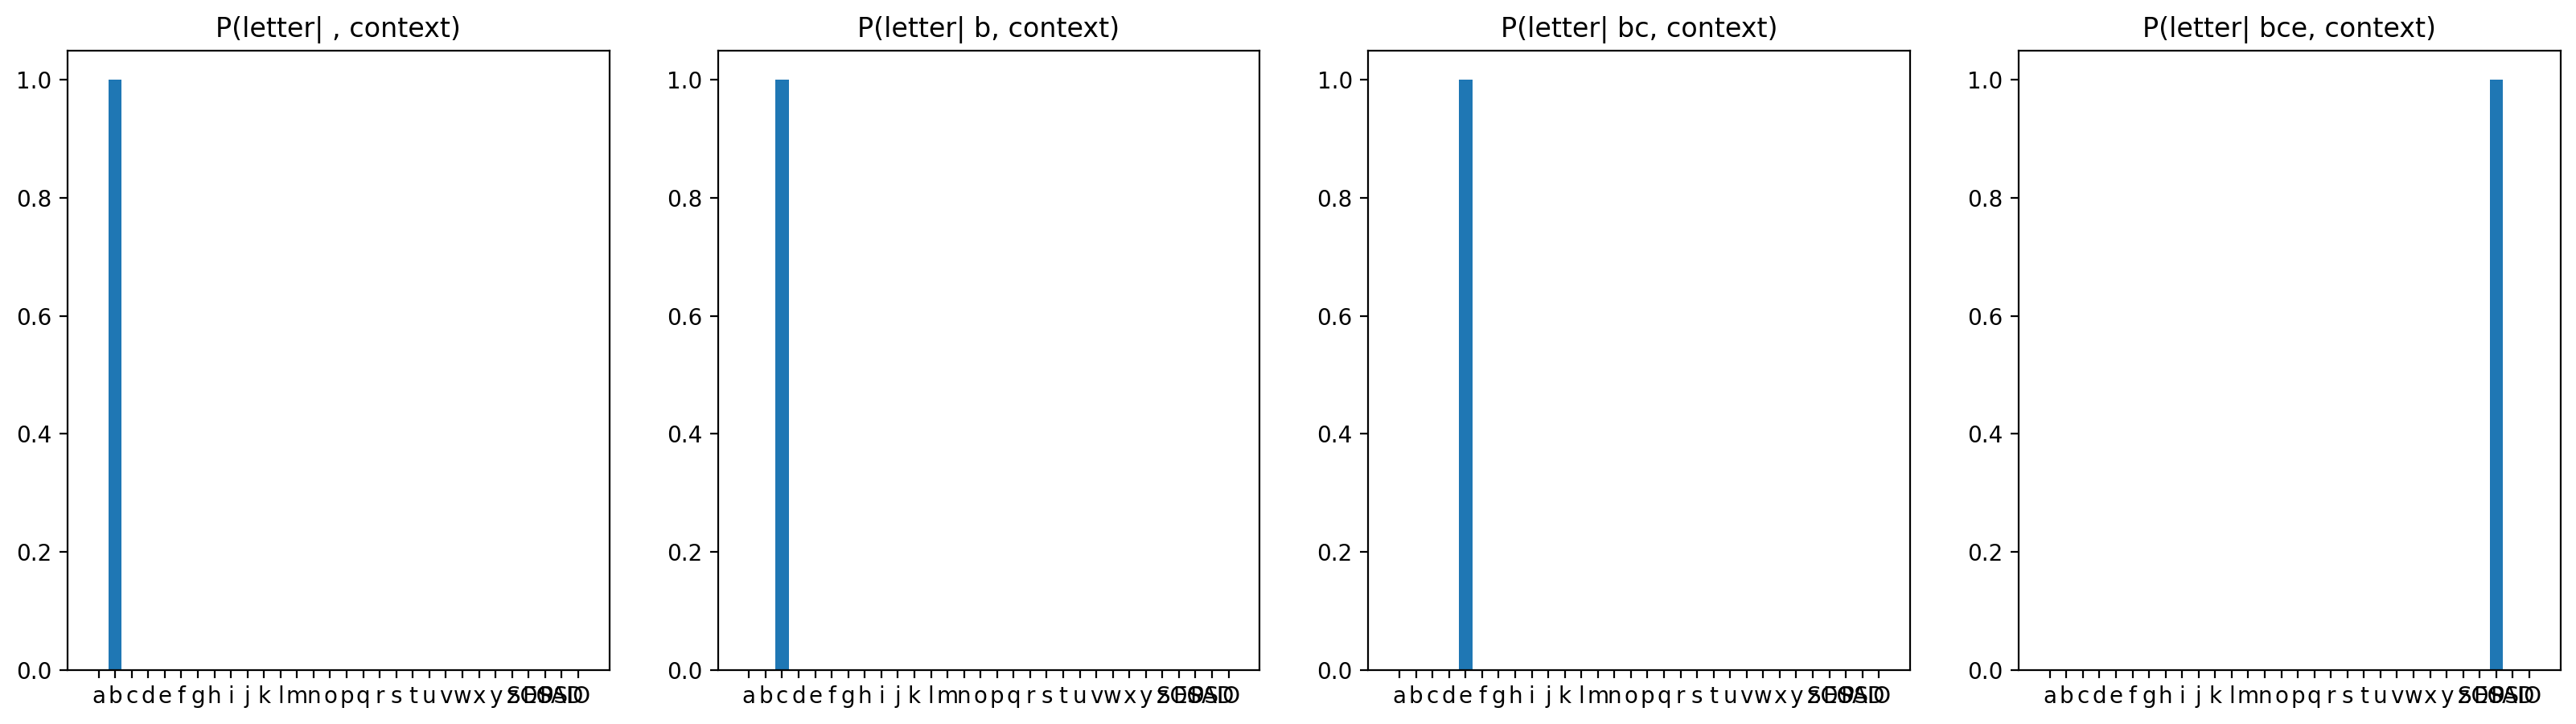

In [229]:
memory = hidden_states_succ["layer_2"]
predictions_unperturbed, logits = decoderlens.predict_batch(
    memory, 
    batch, 
    dataloader.dataset.langs,
    20,
    return_logits=True
    )
print(predictions_unperturbed[0])
plot_probs(predictions_unperturbed[0], logits[0], dataloader.dataset.langs["output"])

['a', 'c', 'd']


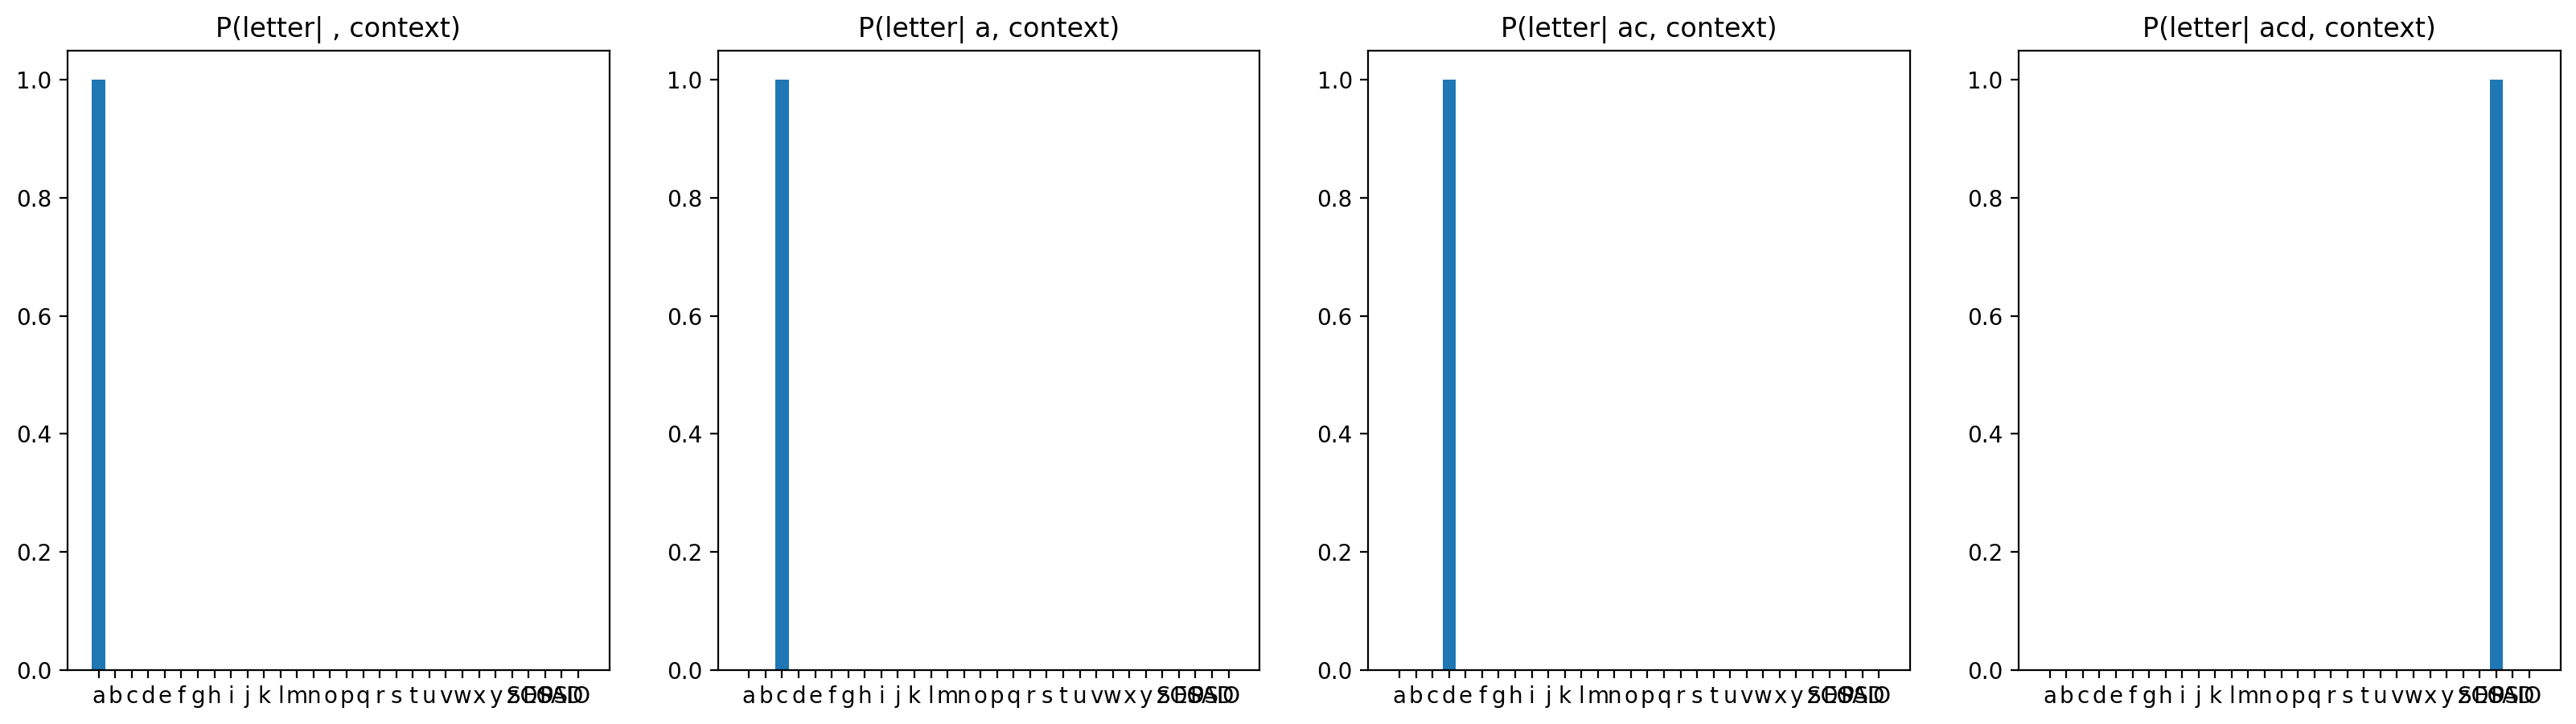

In [231]:
# insert full hidden states from pred example at final layer:
memory = hidden_states_pred["layer_2"]
predictions_perturbed, logits = decoderlens.predict_batch(
    memory, 
    batch, 
    dataloader.dataset.langs,
    20,
    return_logits=True
    )
print(predictions_perturbed[0])
plot_probs(predictions_perturbed[0], logits[0], dataloader.dataset.langs["output"])

### Partial Perturbations

1. Replace the hidden states of the query letters (a,b,c) in the alphabet from successor problem  with hidden states from predecessor problem
2. Replace unaffected alphabet hidden states from successor problem with hidden states from predecessor problem

In [277]:
" ".join(batch["xq_context"][0][9:26])

'j k l m n o p q r s t u v w x y z'

In [266]:
batch["study"]

['g h i > g h j']

['a', 'c', 'd']


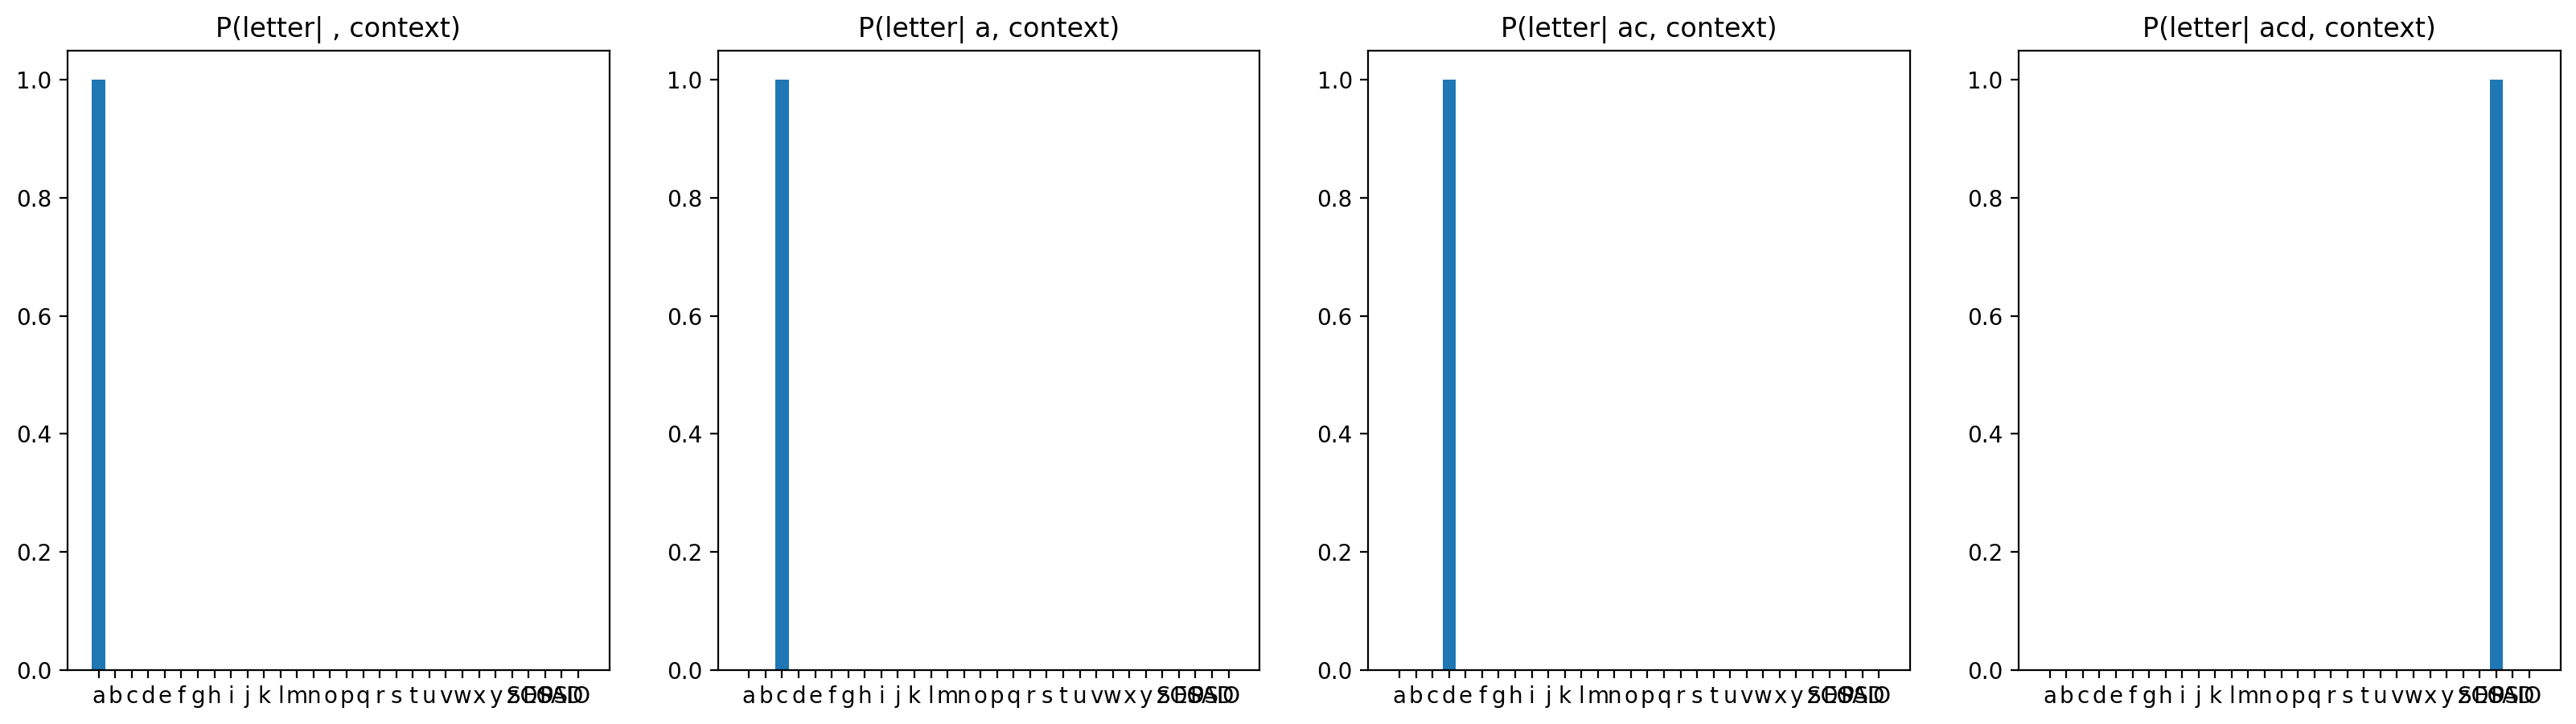

In [272]:
# 1. Replace the hidden states of the query letters in the alphabet with hidden states from predecessor problem
max_idx = 32
mixed_hidden_states = deepcopy(hidden_states_succ["layer_2"])
# replace representations of a b c with pred representations:
mixed_hidden_states[0][:max_idx] = hidden_states_pred["layer_2"][0][:max_idx]
# check that hidden_states have been copied
assert torch.all(hidden_states_pred["layer_2"][0][:max_idx,:5] == mixed_hidden_states[0][:max_idx,:5])

memory = mixed_hidden_states
predictions_mixed, logits = decoderlens.predict_batch(
    memory, 
    batch, 
    dataloader.dataset.langs,
    20,
    return_logits=True
    )
print(predictions_mixed[0])
plot_probs(predictions_mixed[0], logits[0], dataloader.dataset.langs["output"])

In [248]:
# 2. Replace unaffected alphabet hidden states from successor problem with hidden states from predecessor problem
lower_limit = 8
upper_limit = 26
print(" ".join(batch["xq_context"][0][lower_limit:upper_limit]))

i j k l m n o p q r s t u v w x y z


['b', 'c', 'e']


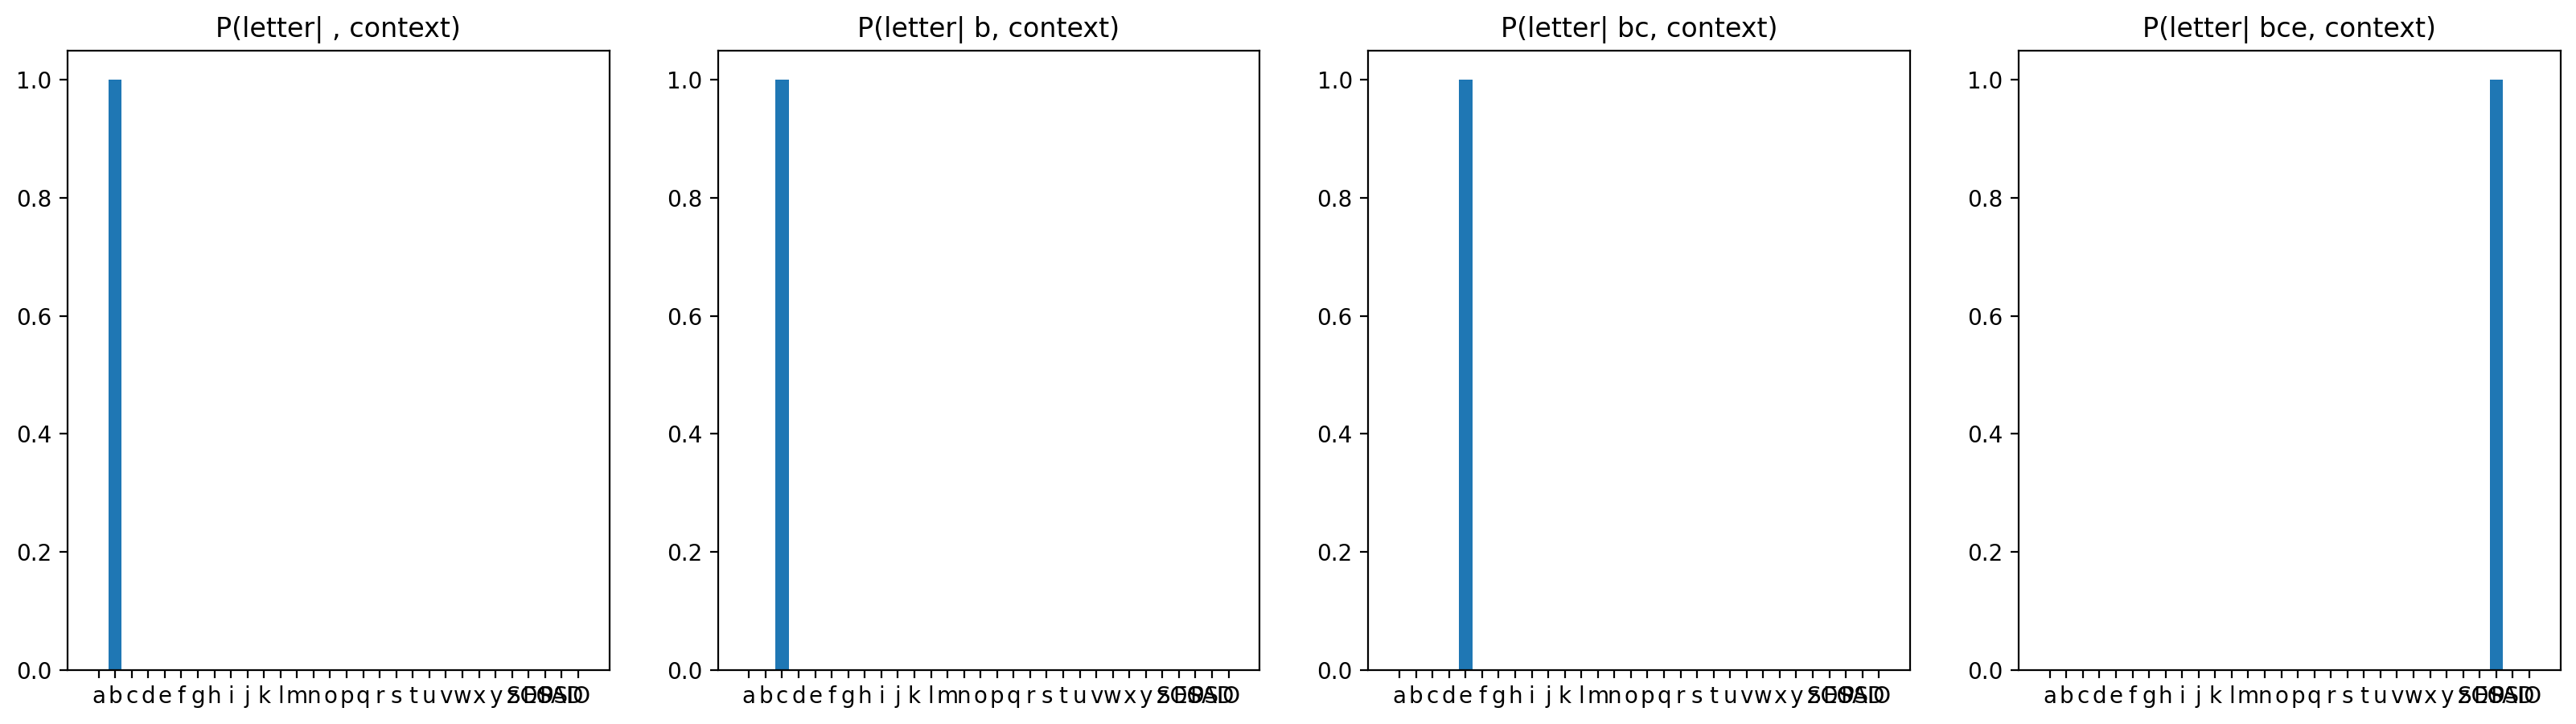

In [249]:
perturbed_idx = range(lower_limit,upper_limit)
mixed_hidden_states = deepcopy(hidden_states_succ["layer_2"])
# replace representations of i,j, ... z with pred representations:
mixed_hidden_states[0][perturbed_idx] = hidden_states_pred["layer_2"][0][perturbed_idx]

# check that hidden_states have been copied
assert torch.all(hidden_states_pred["layer_2"][0][perturbed_idx,:5] == mixed_hidden_states[0][perturbed_idx,:5])

memory = mixed_hidden_states
predictions_mixed, logits = decoderlens.predict_batch(
    memory, 
    batch, 
    dataloader.dataset.langs,
    20,
    return_logits=True
    )
print(predictions_mixed[0])
plot_probs(predictions_mixed[0], logits[0], dataloader.dataset.langs["output"])

In [250]:
print(hidden_states_pred["layer_2"][0, perturbed_idx,:5])
print(hidden_states_succ["layer_2"][0, perturbed_idx,:5])
print(mixed_hidden_states[0, perturbed_idx,:5])

tensor([[ 0.3021,  0.0939,  0.0028,  0.1225, -0.1623],
        [ 0.3012,  0.0981,  0.0235,  0.1139, -0.1386],
        [ 0.2920,  0.1337,  0.0198,  0.1172, -0.1482],
        [ 0.2860,  0.1260,  0.0239,  0.1040, -0.1581],
        [ 0.2778,  0.1127,  0.0265,  0.0970, -0.1417],
        [ 0.2740,  0.1220,  0.0340,  0.0964, -0.1292],
        [ 0.3052,  0.1203,  0.0097,  0.0971, -0.1303],
        [ 0.3072,  0.0775,  0.0183,  0.0881, -0.1002],
        [ 0.2953,  0.1112,  0.0302,  0.0982, -0.1175],
        [ 0.2907,  0.1140,  0.0381,  0.0859, -0.1005],
        [ 0.2989,  0.1126,  0.0536,  0.0832, -0.0909],
        [ 0.2896,  0.1192,  0.0525,  0.0859, -0.1487],
        [ 0.2795,  0.1389,  0.0642,  0.0874, -0.1171],
        [ 0.2785,  0.1108,  0.0622,  0.0951, -0.1295],
        [ 0.2683,  0.1098,  0.0446,  0.0994, -0.1024],
        [ 0.2690,  0.1363,  0.0383,  0.1043, -0.1234],
        [ 0.2501,  0.1449,  0.0195,  0.1120, -0.1366],
        [ 0.1696,  0.0816,  0.0070,  0.0948, -0.1278]])
tensor([[

In [158]:
unperturbed_idx = 1
print(hidden_states_pred["layer_2"][0, unperturbed_idx,:5])
print(hidden_states_succ["layer_2"][0, unperturbed_idx,:5])
print(mixed_hidden_states[0, unperturbed_idx,:5])

tensor([ 0.0550, -0.1540,  0.0360,  0.1906,  0.3132])
tensor([ 0.1775, -0.1472, -0.0917,  0.1635,  0.2929])
tensor([ 0.1775, -0.1472, -0.0917,  0.1635,  0.2929])


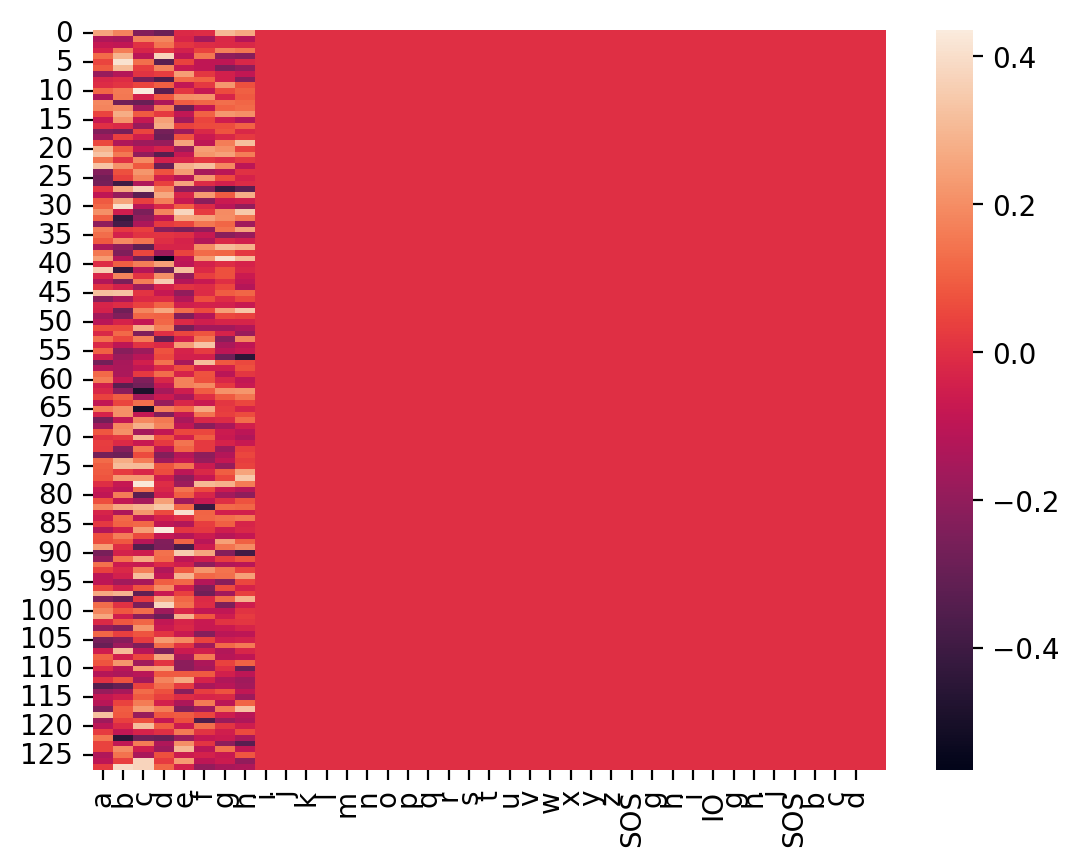

Predicted Sequence: ['b', 'c', 'd', 'e', 'f']


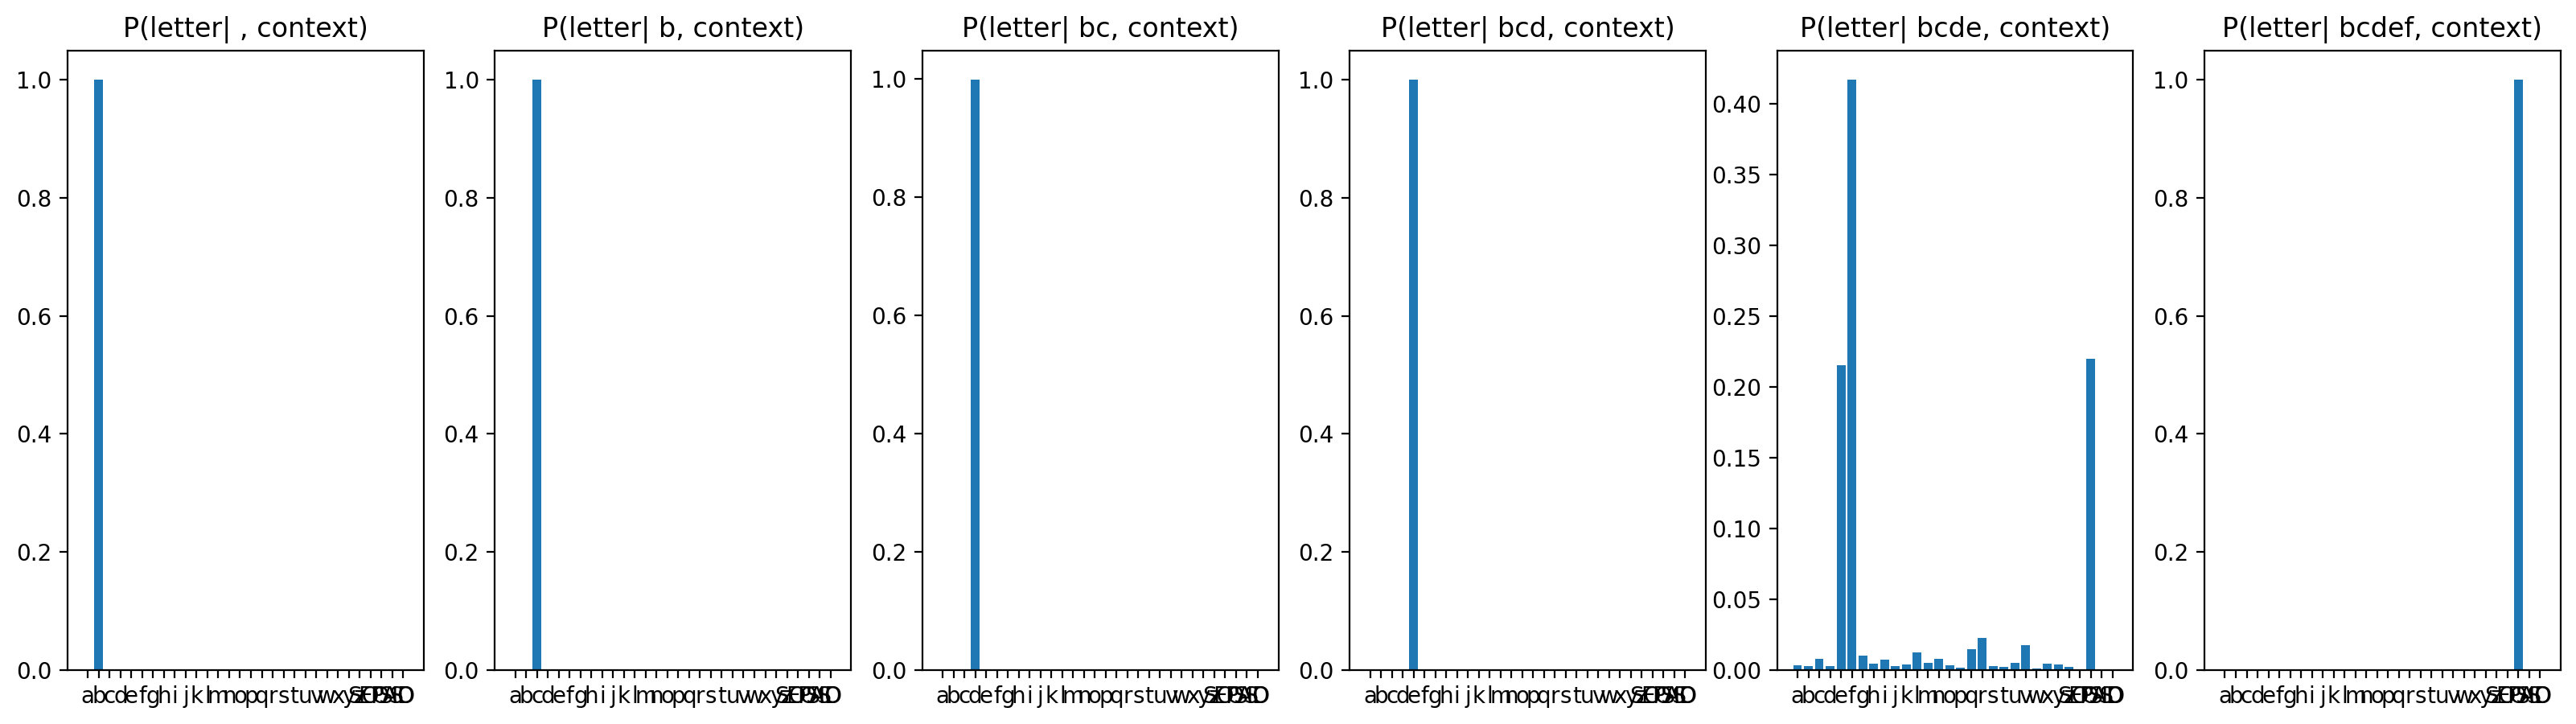

In [317]:
perturbed_idx = range(lower_limit,upper_limit)
mixed_hidden_states = deepcopy(hidden_states_succ["layer_2"])
# mixed_hidden_states[0,8:26] = 0
# mixed_hidden_states[0,8:27] = 0
mixed_hidden_states[0,8:] = 0
# check that hidden_states have been copied
# assert torch.all(hidden_states_pred["layer_2"][0][perturbed_idx,:5] == mixed_hidden_states[0][perturbed_idx,:5])

sns.heatmap(
    mixed_hidden_states[0].T, 
    xticklabels=batch["xq_context"][0],
    cbar=True
)
plt.show("Perturbed Hidden States")
plt.show()

memory = mixed_hidden_states
predictions_mixed, logits = decoderlens.predict_batch(
    memory, 
    batch, 
    dataloader.dataset.langs,
    20,
    return_logits=True
    )
print(f"Predicted Sequence: {predictions_mixed[0]}")
plot_probs(predictions_mixed[0], logits[0], dataloader.dataset.langs["output"])